In [1]:
import torch # torch will allow us to create tensors.
import torch.nn as nn # torch.nn allows us to create a neural network and allows
                      # us to access a lot of useful functions like:
                      # nn.Linear, nn.Embedding, nn.CrossEntropyLoss() etc.

from torch.optim import Adam # optim contains many optimizers. This time we're using Adam
from torch.distributions.uniform import Uniform # So we can initialize our tensors with a uniform distribution
from torch.utils.data import TensorDataset, DataLoader # these are needed for the training data

import lightning as L # lightning has tons of cool tools that make neural networks easier

import pandas as pd ## to create dataframes from graph input
import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

In [2]:
## create the training data for the neural network.
inputs = torch.tensor([[1., 0., 0., 0.], # one-hot-encoding for Troll 2...
                       [0., 1., 0., 0.], # ...is
                       [0., 0., 1., 0.], # ...great
                       [0., 0., 0., 1.]]) # ...Gymkata

labels = torch.tensor([[0., 1., 0., 0.], # "Troll 2" is followed by "is"
                       [0., 0., 1., 0.], # "is" is followed by "great"
                       [0., 0., 0., 1.], # "great" isn't followed by anything, but we'll pretend it was followed by "Gymkata"
                       [0., 1., 0., 0.]]) # "Gymkata", just like "Troll 2", is followed by "is".

In [3]:
dataset = TensorDataset(inputs, labels) 
dataloader = DataLoader(dataset)

In [4]:
class WordEmbeddingWithLinear(L.LightningModule):

    def __init__(self):
        
        super().__init__()
        
        ## The first thing we do is set the seed for the random number generorator.
        ## This ensures that when someone creates a model from this class, that model
        ## will start off with the exact same random numbers as I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)
        
        ## In order to initialize weights from the 4 inputs (one for each unique word) 
        ##       to the 2 nodes in the hidden layer (top and bottom nodes), we simply make
        ##       one call to nn.Linear() where in_features specifies the number of
        ##       inputs and out_features specifies the number of nodes we
        ##       are connecting them to. Since we don't want to use bias terms,
        ##       we set bias=False
        self.input_to_hidden = nn.Linear(in_features=4, out_features=2, bias=False)
        ## Now, in order to connect the 2 nodes in the hidden layer to the 4 outputs, we
        ##       make one call to nn.Linear(), where in_features specifies the number of
        ##       nodes in hidden layer and out_features specifies the number of output values we want.
        ##       And again, we can set bias=False
        self.hidden_to_output = nn.Linear(in_features=2, out_features=4, bias=False)
        
        ## We'll use CrossEntropyLoss in training_step()
        self.loss = nn.CrossEntropyLoss()
        
        
    def forward(self, input): 
        
        ## Unlike before, where we did all the math by hand, now we can
        ## simply pass the input values to the weights we created with nn.Linear() 
        ## between the input and the hidden layer and save the result in "hidden"
        ##
        ## NOTE: Unlike before, we don't need to strip off the extra brackets from the
        ##       input. the Linear ojbect knows what to do.
        hidden = self.input_to_hidden(input)
        
        ## Then we pass "hidden" to the weights we created with nn.Linear() 
        ## between the hidden layer and the output.
        output_values = self.hidden_to_output(hidden)
                
        return(output_values)
        
        
    def configure_optimizers(self): 
        # this configures the optimizer we want to use for backpropagation.
        
        return Adam(self.parameters(), lr=0.1)

    
    def training_step(self, batch, batch_idx): 
        # take a step during gradient descent.
        
        input_i, label_i = batch # collect input
        output_i = self.forward(input_i) # run input through the neural network
        loss = self.loss(output_i, label_i) ## loss = cross entropy
                    
        return loss

In [5]:
modelLinear = WordEmbeddingWithLinear() 

print("Before optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, torch.round(param.data, decimals=2))

Seed set to 42


Before optimization, the parameters are...
input_to_hidden.weight tensor([[ 0.3800,  0.4200, -0.1200,  0.4600],
        [-0.1100,  0.1000, -0.2400,  0.2900]])
hidden_to_output.weight tensor([[ 0.6200, -0.5200],
        [ 0.6100,  0.1300],
        [ 0.5200,  0.1000],
        [ 0.3400, -0.1000]])


In [6]:
data = {
    ## NOTE: Unlike before, when we called item() on each individual
    ##       Weight, now that we are using nn.Linear, we access the
    ##       Weights with ".weight". We then have to remove the gradients
    ##       associated with each Weight, so we also call .detach().
    ##       Lastly, we then convert the tensor to a numpy array with
    ##       numpy().
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(), # [0] = Weights to top activation function
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(), # [1] = Weights to bottom activation function
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,0.382269,-0.109552,Troll2,input1
1,0.415004,0.100895,is,input2
2,-0.117136,-0.243428,great,input3
3,0.459306,0.293641,Gymkata,input4


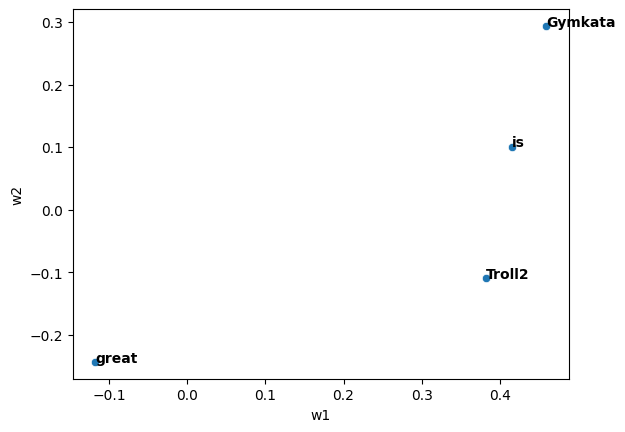

In [7]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph

## Troll 2
plt.text(df.w1[0], df.w2[0], df.token[0], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold') 
## is
plt.text(df.w1[1], df.w2[1], df.token[1], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')
## great
plt.text(df.w1[2], df.w2[2], df.token[2], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

## Gymkata
plt.text(df.w1[3], df.w2[3], df.token[3], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

plt.show()

In [8]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelLinear, train_dataloaders=dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Bryan Ngu\Desktop\UM_Intern\env\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | input_to_hidden 

Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 260.63it/s, v_num=6]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 175.20it/s, v_num=6]


In [9]:
print("After optimization, the parameters are...")
for name, param in modelLinear.named_parameters():
    print(name, param.data)

After optimization, the parameters are...
input_to_hidden.weight tensor([[ 2.5104, -1.0177, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8190, -0.2228]])
hidden_to_output.weight tensor([[-0.3022, -1.0102],
        [ 3.2008, -0.3850],
        [-0.6693,  2.1814],
        [-2.6841, -2.9578]])


In [10]:
data = {
    "w1": modelLinear.input_to_hidden.weight.detach()[0].numpy(),
    "w2": modelLinear.input_to_hidden.weight.detach()[1].numpy(),
    "token": ["Troll2", "is", "great", "Gymkata"],
    "input": ["input1", "input2", "input3", "input4"]
}
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,2.510447,-0.068821,Troll2,input1
1,-1.017650,2.482441,is,input2
2,-1.974159,-1.818951,great,input3
3,2.435523,-0.222807,Gymkata,input4


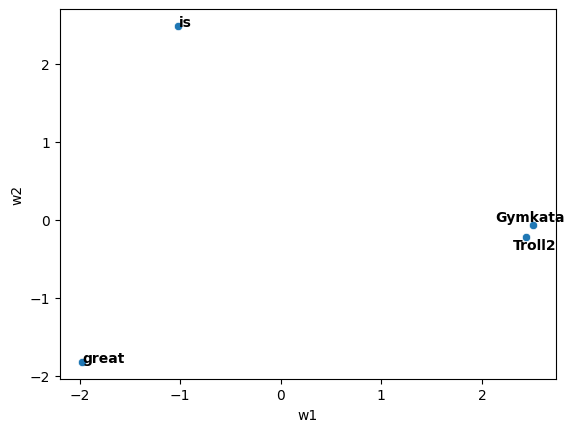

In [11]:
sns.scatterplot(data=df, x="w1", y="w2")

## add the token each dot represents to the graph
## NOTE: For Troll2 and and Gymkata, we're adding offsets to where to print the tokens because otherwise
## they will be so close to each other that they will overlap and be unreadable.

# Troll 2
plt.text(df.w1[0]-0.2, df.w2[0]-0.3, df.token[0], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold') 

# is
plt.text(df.w1[1], df.w2[1], df.token[1], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

# great
plt.text(df.w1[2], df.w2[2], df.token[2], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

# Gymkata
plt.text(df.w1[3]-0.3, df.w2[3]+0.2, df.token[3], 
         horizontalalignment='left', 
         size='medium', 
         color='black', 
         weight='semibold')

plt.show()

In [12]:
## Let's see what the model predicts
softmax = nn.Softmax(dim=1) ## dim=0 applies softmax to rows, dim=1 applies softmax to columns

print(torch.round(softmax(modelLinear(torch.tensor([[1., 0., 0., 0.]]))), decimals=2)) ## print the predictions for "Troll2"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 1., 0., 0.]]))), decimals=2)) ## print the predictions for "is"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 1., 0.]]))), decimals=2)) ## print the predictions for "great"
print(torch.round(softmax(modelLinear(torch.tensor([[0., 0., 0., 1.]]))), decimals=2)) ## print the predictions for "Gymkata"

tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 1., 0.]], grad_fn=<RoundBackward1>)
tensor([[0., 0., 0., 1.]], grad_fn=<RoundBackward1>)
tensor([[0., 1., 0., 0.]], grad_fn=<RoundBackward1>)


In [13]:
modelLinear.input_to_hidden.weight

Parameter containing:
tensor([[ 2.5104, -1.0177, -1.9742,  2.4355],
        [-0.0688,  2.4824, -1.8190, -0.2228]], requires_grad=True)

In [14]:
##  NOTE: We have to transpose the original embedding values (from w1 and w2) for nn.Embedding()
##        and we do this with adding a '.T' to modelLinear.input_to_hidden.weight.T
word_embedings = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T)

In [15]:
word_embedings.weight

Parameter containing:
tensor([[ 2.5104, -0.0688],
        [-1.0177,  2.4824],
        [-1.9742, -1.8190],
        [ 2.4355, -0.2228]])

In [16]:
word_embedings(torch.tensor(0)) # retrieve the embedding values for Troll 2...

tensor([ 2.5104, -0.0688])

In [17]:
vocab = {'Troll2': 0,
         'is': 1,
         'great': 2,
         'Gymkata': 3}

In [18]:
word_embedings(torch.tensor(vocab['Troll2']))

tensor([ 2.5104, -0.0688])

In [19]:
word_embedings(torch.tensor(vocab['Gymkata']))

tensor([ 2.4355, -0.2228])